# Cross-Lingual Noise Direction Analysis
## Clean notebook — parallel JSONL input

Input: two JSONL files (EN and ES), each with `{"noisy": ..., "clean": ...}` per line.
Sentences are parallel (same index = same meaning).

Runs XLM-R, NLLB, and CANINE. Outputs per-pair and aggregate analysis.

In [ ]:
!pip install -q transformers torch numpy scikit-learn matplotlib sentencepiece protobuf

In [ ]:
import json
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel, AutoModelForSeq2SeqLM
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Load Data

Upload your two JSONL files (EN and ES) to Colab, or paste inline below.

In [ ]:
# Option 1: Load from uploaded JSONL files
# en_data = [json.loads(l) for l in open('en_pairs.jsonl')]
# es_data = [json.loads(l) for l in open('es_pairs.jsonl')]

# Option 2: Paste inline
en_raw ="""
{"noisy": "yeh but still that's wild lol", "clean": "Yes, but that is still crazy haha"}
{"noisy": "haha oh okk ! yeaah , they've been dating for a while now !! they seem crazy cute !!!", "clean": "Haha, oh, okay! Yes, they have been dating for a while now! They seem crazy cute!"}
{"noisy": "best snapchat i've seen all dayyyyyy lmfao", "clean": "Best snapchat I have seen all day hahahahhaha"}
{"noisy": "lol . don't act cute here pls", "clean": "Haha, do not act cute here, please"}
{"noisy": "idek why i bother ... smh", "clean": "I don't know why i bother... I can't believe it"}
{"noisy": "umm i thouuuuught thaaaaat convo was pretty funny soooooo", "clean": "Mmm... I thought that conversation was pretty funny, so..."}
{"noisy": "stop be so fucken gay you three aint nobody got time for that", "clean": "Stop being so fucking gay, you three are not, nobody has time for that."}
{"noisy": "im starting to blieve that im way to much for u", "clean": "I am starting to believe that I am way to much for you"}
{"noisy": "idk . but i know for damn sure i ain driving her nowhere lmao", "clean": "I don't know, but I know for damn sure I am driving her nowhere hahahaha"}
{"noisy": "oh you finished msges lol hw much you chat ha ! :p", "clean": "Oh, you finished messages, haha, how much you chat, ha!"}
{"noisy": "i'm bored outta my mind and i'm not sopposed to be on here lol", "clean": "I am bored out of my mind, and I am not supposed to be in here, haha"}
{"noisy": "with your beleive , u must receive , soo don't be deceived , with god , all things are possible . #hapibufdedamooz!?", "clean": "With your belief, you must receive, so don't be deceived, with God all things are possible. #hapibufdedamooz"}
{"noisy": "resellers probably , haha tryin to squash the competition and get more pairs .", "clean": "Resellers, probably, trying to squash the competition and get more pairs."}
{"noisy": "after the exam when everyones discussiiiiing answers & u wrote nothing similar", "clean": "After the exam, when everyone is discussing answers and you wrote nothing similar"}
{"noisy": "i know . im thinking im finna walk back outside and shit", "clean": "I know. I am thinking I am fine to walk back outside and all"}
{"noisy": "is it just me or it's really fucking hot !? merde alors !!!!", "clean": "Is it just me, or it is really fucking hot? Merde, alors!"}
{"noisy": "the fucking video of zayn and louis smoking im layghing my ass off haha", "clean": "The fucking video of Zayn and Louis smoking, I am laughing my ass off haha"}
{"noisy": "hey gma , broadcasting the zouis video won't make you a better network k bye -zel", "clean": "Hey, GMA, broadcasting the Zouis video won't make you a better network, ok? Bye -Zel"}
{"noisy": "kim kardashian & kanye weeest r husband and wife !", "clean": "Kim Kardashian and Kanye West are husband and wife!"}
{"noisy": "lmfao do u remember when harry got grounded for saying ' pussy ' on live national tv", "clean": "Hahahahhaha do you remember when harry got grounded for saying 'pussy' on live national TV?"}
{"noisy": "i'll try and use it in the news tomorrow ! haha x", "clean": "I will try and use it in the news tomorrow! haha"}
{"noisy": "another gain tweet iiiiin 5 mins get stalking or u missit", "clean": "Another gained tweet in five minutes, get stalking or you miss it"}
{"noisy": "im feelin like malcom in the middleee loool", "clean": "I am feeling like Malcolm in the middle haha"}
{"noisy": "btfol lmfaoo now dat was aaaa good laugh", "clean": "Hahahahahaha hahahahhaha, now that was a good laugh"}
{"noisy": "my mom just asked if boys at my school shave their armpits ... umm wuuuut ????!?!?", "clean": "My mom just has asked if boys at my school shave their armpits... Mmm what?"}
"""
es_raw = """
{"noisy": "seee pero igual es super loco lol", "clean": "Sí, pero de todos modos es una locura, haha"}
{"noisy": "haha ah okk ! siii , hace tiempo ya q salen !! son monisimos !!!", "clean": "¡Haha, ah, okey! ¡Sí, ya hace un tiempo que salen! ¡Son muy monos!"}
{"noisy": "mejor snapchat q vi en todo el diaaaaaaa lmfao", "clean": "El mejor snapchat que ví en todo el día jajajajaj"}
{"noisy": "lol . no te hagas el mono aqui porfa", "clean": "Haha, no te hagas el mono aquí, por favor"}
{"noisy": "ni se xq me molesto ... ayayayya", "clean": "Ni siquiera sé por qué me molesto... No puedo creerlo"}
{"noisy": "umm me parecioooooooo queesaaaaaa platika era bastante graciosa asiqqqqqqq", "clean": "Mmm... me pareció que la conversación era bastante graciosa, así que..."}
{"noisy": "dejad de ser tan pto gays los tres no lo sois no tenemos tiempo pa esto", "clean": "Dejad de ser tan gays, ninguno de los tres lo es, no tenemos tiempo para esto."}
{"noisy": "toy mpezando a pensar q soy demasiado pa ti", "clean": "Estoy empezando a pensar que soy demasiado para ti"}
{"noisy": "nse . pero si q se q no la llevo a ningun sitio njasjajabncj", "clean": "No lo sé, pero lo que sí sé es que no la llevaré a ningún sitio hahahaha"}
{"noisy": "ah has terminao los msjes lol mae mia cuanto chateas ha ! :p", "clean": "Ah, has terminado los mensajes, haha, ¡cuánto chateas, ha!"}
{"noisy": "stoy mega aburrida y no debería star aki lol", "clean": "Estoy muy aburrida, y no debería estar aquí, haha"}
{"noisy": "con tu fe , debs recivir , asiqqq no te dejes engañar, con dios, todo es posible. #hapibufdedamooz!?", "clean": "Con tu Fe, debes recibir, así que no te dejes engañar, con Dios todo es posible. #hapibufdedamooz"}
{"noisy": "seguro revenderores , jjaj tratand de aplastar a la competencia y quedarse con más .", "clean": "Revendedores, seguramente, tratando de aplastar a la competencia y quedarse con más."}
{"noisy": "después del examen cuando todos se diceeeeeen las respuestas y no escrbiste nada parecido", "clean": "Después del examen, cuando todos se dicen las respuestas y tú no escribiste nada parecido"}
{"noisy": "lo se . stoy pensando q toy bn para caminar otra vz afuera y kk", "clean": "Lo sé. Estoy pensando que estoy bien para caminar otra vez hacia afuera y eso."}
{"noisy": "soy yo o hace un puto calor !? mierda !!!!", "clean": "¿Soy yo, o hace muchísimo calor? ¡Mierda!"}
{"noisy": "el pñtero video de zayn y louis fumndo me meo de risa haha", "clean": "El puñetero video de Zayn y Louis fumando, me muero de la risa haha"}
{"noisy": "ey gma , pasar el video de zouis no t hace un mejor canal ok bye -zel", "clean": "Oye, GMA, reproducir el video de Zouis no te hace un mejor canar, ¿ok? Adiós -Zel"}
{"noisy": "kim kardashian & kanye weeest se casaronnnn !", "clean": "Kim Kardashian y Kanye West se casaron!"}
{"noisy": "lmfao t acuerdas cuando a harry lo castigaron x decir ' coño ' en vivo en la tele", "clean": "Jajajajaj ¿te acuerdas de cuando castigaron a Harry por decir 'coño' en vivo en la televisión?"}
{"noisy": "voy a tratar de usarlo en las notiicas mñn ! haha x", "clean": "¡Voy a tratar de usarlo en las noticias mañana! Haha"}
{"noisy": "otro tuit ganado eeeeeen 5 mins ponte a stalkear o te lo pierdssss", "clean": "Otro tweet ganado en cinco minutos, ponte a estalkear o te lo pierdes."}
{"noisy": "me 100to cmo malcolm el d en medio loool", "clean": "Me siento como Malcolm, el de en medio hahaha"}
{"noisy": "me meo de risaaaaa lmfaoo qué buen chisteeeee", "clean": "Me muero de la risa jajajajaja, eso fue un buen chiste"}
{"noisy": "mi mama m acaba de preguntar si los chikos de mi scuela se rasuran el sobaco ... perrrdona ????!?!?", "clean": "Mi mamá me acaba de preguntar si los chicos de mi escuela se rasuran las axilas... Mmm ¿cómo?"}
"""

en_data = [json.loads(l) for l in en_raw.strip().split('\n') if l.strip()]
es_data = [json.loads(l) for l in es_raw.strip().split('\n') if l.strip()]

assert len(en_data) == len(es_data), f'Mismatch: {len(en_data)} EN vs {len(es_data)} ES'
n = len(en_data)

en_clean = [d['clean'] for d in en_data]
en_noisy = [d['noisy'] for d in en_data]
es_clean = [d['clean'] for d in es_data]
es_noisy = [d['noisy'] for d in es_data]

print(f'Loaded {n} parallel pairs')
print(f'Example EN: {en_clean[0][:60]} → {en_noisy[0][:60]}')
print(f'Example ES: {es_clean[0][:60]} → {es_noisy[0][:60]}')

Loaded 25 parallel pairs
Example EN: Yes, but that is still crazy haha → yeh but still that's wild lol
Example ES: Sí, pero de todos modos es una locura, haha → seee pero igual es super loco lol


## Embedding extraction

In [ ]:
def get_embeddings(sentences, tokenizer, model, device, max_length=128):
    embeddings = []
    with torch.no_grad():
        for sent in sentences:
            inputs = tokenizer(sent, return_tensors='pt', truncation=True,
                               max_length=max_length, padding=True).to(device)
            outputs = model(**inputs)
            mask = inputs['attention_mask'].unsqueeze(-1)
            hidden = outputs.last_hidden_state
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
            embeddings.append(pooled.cpu().numpy().flatten())
    return np.array(embeddings)

def get_nllb_encoder_embeddings(sentences, tokenizer, model, device, src_lang):
    tokenizer.src_lang = src_lang
    embeddings = []
    with torch.no_grad():
        for sent in sentences:
            inputs = tokenizer(sent, return_tensors='pt', truncation=True,
                               max_length=128, padding=True).to(device)
            encoder_outputs = model.model.encoder(**inputs)
            mask = inputs['attention_mask'].unsqueeze(-1)
            hidden = encoder_outputs.last_hidden_state
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
            embeddings.append(pooled.cpu().numpy().flatten())
    return np.array(embeddings)

## Analysis functions

In [ ]:
def analyze_direction(emb_en_clean, emb_en_noisy, emb_es_clean, emb_es_noisy,
                      en_clean, en_noisy, es_clean, es_noisy, model_name):
    """Full analysis: baseline sim, direction consistency, cross-lingual transfer, per-pair."""
    n = len(en_clean)

    # Difference vectors
    en_diffs = emb_en_noisy - emb_en_clean
    es_diffs = emb_es_noisy - emb_es_clean

    # Average directions
    en_dir = en_diffs.mean(axis=0)
    es_dir = es_diffs.mean(axis=0)

    # Baseline similarities
    en_baselines = [cosine_similarity(emb_en_clean[i:i+1], emb_en_noisy[i:i+1])[0,0] for i in range(n)]
    es_baselines = [cosine_similarity(emb_es_clean[i:i+1], emb_es_noisy[i:i+1])[0,0] for i in range(n)]

    # Direction consistency
    en_consist = cosine_similarity(en_diffs, en_dir.reshape(1,-1)).flatten()
    es_consist = cosine_similarity(es_diffs, es_dir.reshape(1,-1)).flatten()

    # Cross-lingual: average direction
    cross_dir = cosine_similarity(en_dir.reshape(1,-1), es_dir.reshape(1,-1))[0,0]

    # Cross-lingual: per-pair
    pair_cross = [cosine_similarity(en_diffs[i:i+1], es_diffs[i:i+1])[0,0] for i in range(n)]

    # Shift improvement
    es_shifted = emb_es_clean + en_dir
    improvements = [cosine_similarity(es_shifted[i:i+1], emb_es_noisy[i:i+1])[0,0] -
                    cosine_similarity(emb_es_clean[i:i+1], emb_es_noisy[i:i+1])[0,0]
                    for i in range(n)]

    # Print summary
    print(f'\n{"="*70}')
    print(f'{model_name} SUMMARY')
    print(f'{"="*70}')
    print(f'  EN baseline sim:          {np.mean(en_baselines):.4f} (std {np.std(en_baselines):.4f})')
    print(f'  ES baseline sim:          {np.mean(es_baselines):.4f} (std {np.std(es_baselines):.4f})')
    print(f'  EN direction consistency:  {en_consist.mean():.4f}')
    print(f'  ES direction consistency:  {es_consist.mean():.4f}')
    print(f'  Cross-lingual direction:   {cross_dir:.4f}')
    print(f'  Per-pair cross-lingual:    {np.mean(pair_cross):.4f} (std {np.std(pair_cross):.4f})')
    print(f'  ES improvement from shift: {np.mean(improvements):+.4f}')
    print(f'  Pairs with positive shift: {sum(1 for x in improvements if x > 0)}/{n}')

    return {
        'model': model_name,
        'en_baselines': en_baselines,
        'es_baselines': es_baselines,
        'en_consist': en_consist,
        'es_consist': es_consist,
        'cross_dir': cross_dir,
        'pair_cross': pair_cross,
        'improvements': improvements,
        'en_dir': en_dir,
        'es_dir': es_dir,
    }

In [ ]:
def print_per_pair(results, en_clean, en_noisy, es_clean, es_noisy):
    """Print per-pair details sorted by cross-lingual similarity."""
    n = len(en_clean)
    pc = results['pair_cross']
    sorted_idx = np.argsort(pc)[::-1]

    print(f'\n{"="*70}')
    print(f'{results["model"]} — PER PAIR (sorted by cross-lingual sim)')
    print(f'{"="*70}')

    for rank, i in enumerate(sorted_idx):
        print(f'\n  [{pc[i]:+.3f}] EN: {en_clean[i][:50]}')
        print(f'          →  {en_noisy[i][:50]}')
        print(f'          ES: {es_clean[i][:50]}')
        print(f'          →  {es_noisy[i][:50]}')
        print(f'          EN baseline: {results["en_baselines"][i]:.4f}  '
              f'ES baseline: {results["es_baselines"][i]:.4f}  '
              f'EN consist: {results["en_consist"][i]:.4f}  '
              f'ES consist: {results["es_consist"][i]:.4f}')

## Model 1: XLM-R

In [ ]:
xlmr_tok = AutoTokenizer.from_pretrained('xlm-roberta-base')
xlmr_mod = AutoModel.from_pretrained('xlm-roberta-base').to(device)
xlmr_mod.eval()

print('Extracting XLM-R embeddings...')
xlmr_en_c = get_embeddings(en_clean, xlmr_tok, xlmr_mod, device)
xlmr_en_n = get_embeddings(en_noisy, xlmr_tok, xlmr_mod, device)
xlmr_es_c = get_embeddings(es_clean, xlmr_tok, xlmr_mod, device)
xlmr_es_n = get_embeddings(es_noisy, xlmr_tok, xlmr_mod, device)

xlmr_results = analyze_direction(xlmr_en_c, xlmr_en_n, xlmr_es_c, xlmr_es_n,
                                  en_clean, en_noisy, es_clean, es_noisy, 'XLM-R')
print_per_pair(xlmr_results, en_clean, en_noisy, es_clean, es_noisy)

del xlmr_mod
torch.cuda.empty_cache()
print('\nXLM-R freed.')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting XLM-R embeddings...

XLM-R SUMMARY
  EN baseline sim:          0.9979 (std 0.0014)
  ES baseline sim:          0.9968 (std 0.0019)
  EN direction consistency:  0.6132
  ES direction consistency:  0.6480
  Cross-lingual direction:   0.8581
  Per-pair cross-lingual:    0.5087 (std 0.1823)
  ES improvement from shift: +0.0009
  Pairs with positive shift: 23/25

XLM-R — PER PAIR (sorted by cross-lingual sim)

  [+0.886] EN: Kim Kardashian and Kanye West are husband and wife
          →  kim kardashian & kanye weeest r husband and wife !
          ES: Kim Kardashian y Kanye West se casaron!
          →  kim kardashian & kanye weeest se casaronnnn !
          EN baseline: 0.9958  ES baseline: 0.9947  EN consist: 0.6016  ES consist: 0.5781

  [+0.725] EN: Resellers, probably, trying to squash the competit
          →  resellers probably , haha tryin to squash the comp
          ES: Revendedores, seguramente, tratando de aplastar a 
          →  seguro revenderores , jjaj tratand de

## Model 2: NLLB

In [ ]:
nllb_tok = AutoTokenizer.from_pretrained('facebook/nllb-200-distilled-600M')
nllb_mod = AutoModelForSeq2SeqLM.from_pretrained('facebook/nllb-200-distilled-600M').to(device)
nllb_mod.eval()

print('Extracting NLLB embeddings...')
nllb_en_c = get_nllb_encoder_embeddings(en_clean, nllb_tok, nllb_mod, device, 'eng_Latn')
nllb_en_n = get_nllb_encoder_embeddings(en_noisy, nllb_tok, nllb_mod, device, 'eng_Latn')
nllb_es_c = get_nllb_encoder_embeddings(es_clean, nllb_tok, nllb_mod, device, 'spa_Latn')
nllb_es_n = get_nllb_encoder_embeddings(es_noisy, nllb_tok, nllb_mod, device, 'spa_Latn')

nllb_results = analyze_direction(nllb_en_c, nllb_en_n, nllb_es_c, nllb_es_n,
                                  en_clean, en_noisy, es_clean, es_noisy, 'NLLB')
print_per_pair(nllb_results, en_clean, en_noisy, es_clean, es_noisy)

del nllb_mod
torch.cuda.empty_cache()
print('\nNLLB freed.')

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Extracting NLLB embeddings...

NLLB SUMMARY
  EN baseline sim:          0.8491 (std 0.0853)
  ES baseline sim:          0.7634 (std 0.1050)
  EN direction consistency:  0.5831
  ES direction consistency:  0.6235
  Cross-lingual direction:   0.8605
  Per-pair cross-lingual:    0.5580 (std 0.1401)
  ES improvement from shift: +0.0731
  Pairs with positive shift: 25/25

NLLB — PER PAIR (sorted by cross-lingual sim)

  [+0.825] EN: Kim Kardashian and Kanye West are husband and wife
          →  kim kardashian & kanye weeest r husband and wife !
          ES: Kim Kardashian y Kanye West se casaron!
          →  kim kardashian & kanye weeest se casaronnnn !
          EN baseline: 0.8131  ES baseline: 0.7509  EN consist: 0.6527  ES consist: 0.6993

  [+0.785] EN: Mmm... I thought that conversation was pretty funn
          →  umm i thouuuuught thaaaaat convo was pretty funny 
          ES: Mmm... me pareció que la conversación era bastante
          →  umm me parecioooooooo queesaaaaaa platik

## Model 3: CANINE

In [ ]:
from transformers import CanineTokenizer, CanineModel

canine_tok = CanineTokenizer.from_pretrained('google/canine-s')
canine_mod = CanineModel.from_pretrained('google/canine-s').to(device)
canine_mod.eval()

print('Extracting CANINE embeddings...')
canine_en_c = get_embeddings(en_clean, canine_tok, canine_mod, device, max_length=512)
canine_en_n = get_embeddings(en_noisy, canine_tok, canine_mod, device, max_length=512)
canine_es_c = get_embeddings(es_clean, canine_tok, canine_mod, device, max_length=512)
canine_es_n = get_embeddings(es_noisy, canine_tok, canine_mod, device, max_length=512)

canine_results = analyze_direction(canine_en_c, canine_en_n, canine_es_c, canine_es_n,
                                    en_clean, en_noisy, es_clean, es_noisy, 'CANINE')
print_per_pair(canine_results, en_clean, en_noisy, es_clean, es_noisy)

del canine_mod
torch.cuda.empty_cache()
print('\nCANINE freed.')

tokenizer_config.json:   0%|          | 0.00/854 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/657 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/528M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/246 [00:00<?, ?it/s]

CanineModel LOAD REPORT from: google/canine-s
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting CANINE embeddings...

CANINE SUMMARY
  EN baseline sim:          0.8103 (std 0.0878)
  ES baseline sim:          0.7755 (std 0.0842)
  EN direction consistency:  0.2918
  ES direction consistency:  0.3225
  Cross-lingual direction:   0.4726
  Per-pair cross-lingual:    0.1785 (std 0.1059)
  ES improvement from shift: +0.0043
  Pairs with positive shift: 13/25

CANINE — PER PAIR (sorted by cross-lingual sim)

  [+0.418] EN: Kim Kardashian and Kanye West are husband and wife
          →  kim kardashian & kanye weeest r husband and wife !
          ES: Kim Kardashian y Kanye West se casaron!
          →  kim kardashian & kanye weeest se casaronnnn !
          EN baseline: 0.8049  ES baseline: 0.7549  EN consist: 0.3082  ES consist: 0.4026

  [+0.334] EN: Oh, you finished messages, haha, how much you chat
          →  oh you finished msges lol hw much you chat ha ! :p
          ES: Ah, has terminado los mensajes, haha, ¡cuánto chat
          →  ah has terminao los msjes lol mae 

## Comparison Table

In [ ]:
print(f'\n{"="*90}')
print(f'THREE-MODEL COMPARISON ({n} parallel EN-ES pairs)')
print(f'{"="*90}')
print(f'{"Metric":<35} {"XLM-R":>10} {"NLLB":>10} {"CANINE":>10}')
print(f'{"-"*90}')

for label, key in [('EN baseline sim', 'en_baselines'),
                   ('ES baseline sim', 'es_baselines')]:
    print(f'{label:<35} {np.mean(xlmr_results[key]):>10.4f} '
          f'{np.mean(nllb_results[key]):>10.4f} '
          f'{np.mean(canine_results[key]):>10.4f}')

for label, key in [('EN direction consistency', 'en_consist'),
                   ('ES direction consistency', 'es_consist')]:
    print(f'{label:<35} {xlmr_results[key].mean():>10.4f} '
          f'{nllb_results[key].mean():>10.4f} '
          f'{canine_results[key].mean():>10.4f}')

print(f'{"Cross-lingual direction (avg)":<35} {xlmr_results["cross_dir"]:>10.4f} '
      f'{nllb_results["cross_dir"]:>10.4f} '
      f'{canine_results["cross_dir"]:>10.4f}')

print(f'{"Per-pair cross-lingual (mean)":<35} {np.mean(xlmr_results["pair_cross"]):>10.4f} '
      f'{np.mean(nllb_results["pair_cross"]):>10.4f} '
      f'{np.mean(canine_results["pair_cross"]):>10.4f}')

print(f'{"ES improvement from EN shift":<35} {np.mean(xlmr_results["improvements"]):>10.4f} '
      f'{np.mean(nllb_results["improvements"]):>10.4f} '
      f'{np.mean(canine_results["improvements"]):>10.4f}')

print(f'{"="*90}')


THREE-MODEL COMPARISON (25 parallel EN-ES pairs)
Metric                                   XLM-R       NLLB     CANINE
------------------------------------------------------------------------------------------
EN baseline sim                         0.9979     0.8491     0.8103
ES baseline sim                         0.9968     0.7634     0.7755
EN direction consistency                0.6132     0.5831     0.2918
ES direction consistency                0.6480     0.6235     0.3225
Cross-lingual direction (avg)           0.8581     0.8605     0.4726
Per-pair cross-lingual (mean)           0.5087     0.5580     0.1785
ES improvement from EN shift            0.0009     0.0731     0.0043


## What each metric means

**EN/ES baseline sim** — Average cosine similarity between the clean and noisy embedding of the same sentence, within one language. High (close to 1.0) means the model sees clean and noisy as nearly identical — it compresses the noise away. Low means the model distinguishes them. This tells us how much "noise signal" exists in the representations to work with.

**EN/ES direction consistency** — For each sentence pair, we compute a difference vector (noisy minus clean). Direction consistency is the average cosine similarity between each individual difference vector and the overall average direction. High means all sentences shift in roughly the same direction when made noisy. Low means each sentence shifts differently. This tells us whether there's a single coherent "noise direction" or just random per-sentence perturbations.

**Cross-lingual direction (avg)** — Cosine similarity between the average EN noise direction and the average ES noise direction. High means "making text noisy" pushes embeddings in the same direction regardless of language. This is the headline number for cross-lingual transfer. **Caveat:** this compares two averaged vectors, which are smoother than individual pairs. It can be high even if individual pairs don't align well.

**Per-pair cross-lingual (mean)** — For each parallel sentence pair, cosine similarity between that sentence's EN difference vector and its ES difference vector. Then averaged. This is the stricter test: does the noise direction align for *this specific sentence* across languages, not just on average? The gap between this number and the aggregate direction tells you how much the averaging inflates the result.

**ES improvement from EN shift** — Take each clean ES embedding, add the average EN noise direction to it, measure whether it's now closer to the actual noisy ES embedding (compared to before the shift). Positive means the EN direction moves ES representations in the right direction. This is the most practical metric: can we use the EN-derived direction to predict where noisy ES lives in embedding space?

## Visualization

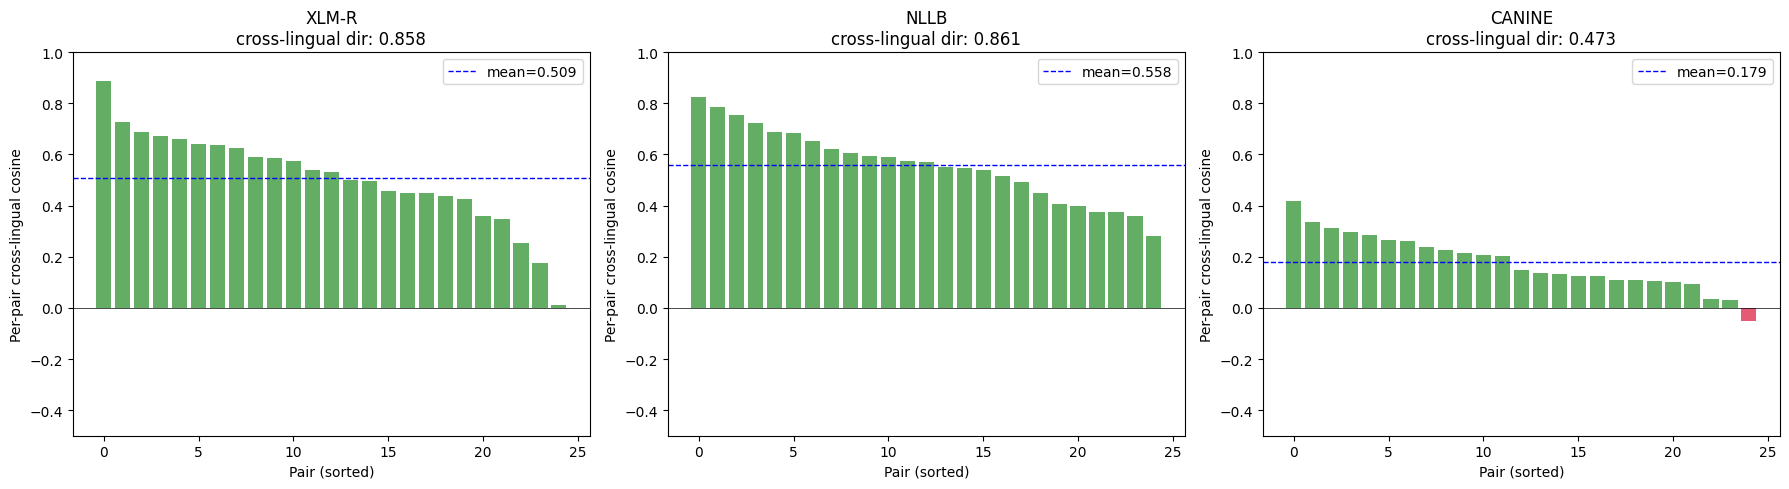

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, results in zip(axes, [xlmr_results, nllb_results, canine_results]):
    pc = results['pair_cross']
    ax.bar(range(n), sorted(pc, reverse=True), color=['forestgreen' if x > 0 else 'crimson' for x in sorted(pc, reverse=True)], alpha=0.7)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhline(y=np.mean(pc), color='blue', linewidth=1, linestyle='--', label=f'mean={np.mean(pc):.3f}')
    ax.set_title(f'{results["model"]}\ncross-lingual dir: {results["cross_dir"]:.3f}')
    ax.set_xlabel('Pair (sorted)')
    ax.set_ylabel('Per-pair cross-lingual cosine')
    ax.set_ylim(-0.5, 1.0)
    ax.legend()

plt.tight_layout()
plt.savefig('three_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings and Interpretation

### What we measured
For 25 parallel EN-ES sentence pairs (each with a clean and noisy version), we computed the clean→noisy difference vector per sentence in three multilingual models, and asked: does this vector point in a similar direction across languages?

### What we found

**1. The aggregate cross-lingual noise direction is high for subword models (~0.86) and low for the character-level model (0.47).**

This replicates our earlier finding on hand-crafted and Instagram DM data. Subword models encode the clean→noisy shift in a way that is broadly shared between EN and ES. The character-level model (CANINE) does not — each sentence shifts in its own direction.

However, "high aggregate direction" does not mean "every sentence aligns." The per-pair cross-lingual cosine averages only 0.51 (XLM-R) and 0.56 (NLLB). About half the pairs align well; the other half don't. The 0.86 is the cosine between two *averaged* vectors, which are smoother and more likely to align than individual pairs. **We cannot claim that the noise direction transfers reliably for any given sentence — only that it transfers on average.**

Before drawing further conclusions, we should run a permutation test: shuffle the clean-noisy pairing within each language, recompute directions, and check whether shuffled directions still produce high cross-lingual cosine. If they do, the finding may be an artifact of averaging in high-dimensional space.

**2. XLM-R barely distinguishes clean from noisy (baseline ~0.997). NLLB distinguishes them clearly (baseline ~0.76-0.85). CANINE distinguishes them most (baseline ~0.78-0.81).**

XLM-R compresses the noise signal — its representations of "u coming tmrw??" and "Are you coming tomorrow?" are nearly identical. This makes XLM-R's high cross-lingual direction (0.86) harder to interpret: the direction exists but is vanishingly small in magnitude. It points the right way but carries almost no information.

NLLB preserves more of the noise signal. Its direction is similarly aligned (0.86) but sits on top of a much larger difference between clean and noisy. This makes NLLB's direction more practically meaningful — there's actually something there to exploit.

The difference between XLM-R and NLLB is not the tokenizer (both use SentencePiece) but the training objective. MLM rewards robustness to surface variation; translation rewards preserving input distinctions.

CANINE sees the noise most clearly (lowest baselines) but can't form a consistent direction because character-level transformations are language-specific: "tmrw" and "mñn" look nothing alike at the character level.

**3. NLLB shows the largest practical improvement from applying the EN direction to ES (0.073). XLM-R shows negligible improvement (0.001). CANINE shows minimal improvement (0.004).**

This means: if you take a clean ES embedding in NLLB and shift it by the EN noise direction, it moves measurably closer to the actual noisy ES embedding. The shift is modest (7%) but consistent. This is the most concrete evidence that the cross-lingual direction carries usable information — at least in NLLB.

### What we don't know yet

- **Is the 0.86 direction cosine statistically significant?** We need the permutation test to rule out that averaging in high-dimensional space inflates this number.
- **What drives the per-pair variance?** Some pairs align well (0.8+), others don't (near 0). Is this about noise type (abbreviations vs. elongation vs. punctuation), sentence length, content, or something else? Annotating pairs by noise type and grouping results would answer this.
- **Is the direction capturing "informality" or surface features?** Lowercase, shorter length, and rare subwords all correlate with noise. We haven't controlled for these. The direction might just encode "this text has unusual surface properties" rather than anything linguistically meaningful about informality.
- **Can any of this be exploited for generation?** Our earlier experiments showed that NLLB's decoder cannot use the shifted encoder representations to produce informal text. The direction is a real phenomenon in the representations but has not yet proven useful for any downstream task.

### What to do next

1. **Permutation test** — validate statistical significance of the cross-lingual direction.
2. **Annotate pairs by noise type** — add a `type` field (abbreviation, elongation, punctuation, mixed) and report per-type cross-lingual alignment. This tests whether universal noise types (elongation, punctuation) transfer better than language-specific ones (abbreviations).
3. **If the above hold up** — proceed to the `spa_noisy_Latn` language tag experiment in NLLB, which uses the model's native architecture rather than embedding arithmetic.

In [ ]:
print(nllb_en_c.shape)

(25, 1024)


In [ ]:
# ============================================================
# CELL 1: Permutation Test — Is NLLB's cross-lingual direction real?
# ============================================================
# We shuffle the clean-noisy pairing within each language,
# breaking the true correspondence. Then recompute the
# cross-lingual direction cosine. If shuffled directions
# still produce ~0.86, the finding is an artifact of
# averaging in high-dimensional space. If they drop to
# near zero, the true pairing carries real signal.
# ============================================================

# Make sure nllb embeddings are still in memory:
# nllb_en_c, nllb_en_n, nllb_es_c, nllb_es_n
# If not, re-run the NLLB cell above (without deleting the model)

n_permutations = 1000
n = len(en_clean)

observed_cross_dir = nllb_results['cross_dir']
observed_pair_cross_mean = np.mean(nllb_results['pair_cross'])
observed_improvement = np.mean(nllb_results['improvements'])
observed_en_consist = nllb_results['en_consist'].mean()
observed_es_consist = nllb_results['es_consist'].mean()

perm_cross_dirs = []
perm_pair_cross_means = []
perm_improvements = []
perm_en_consists = []
perm_es_consists = []

np.random.seed(42)

for p in range(n_permutations):
    # Shuffle noisy embeddings independently per language
    en_shuf_idx = np.random.permutation(n)
    es_shuf_idx = np.random.permutation(n)

    en_diffs_shuf = nllb_en_n[en_shuf_idx] - nllb_en_c
    es_diffs_shuf = nllb_es_n[es_shuf_idx] - nllb_es_c

    en_dir_shuf = en_diffs_shuf.mean(axis=0)
    es_dir_shuf = es_diffs_shuf.mean(axis=0)

    # Aggregate cross-lingual direction
    cd = cosine_similarity(en_dir_shuf.reshape(1,-1), es_dir_shuf.reshape(1,-1))[0,0]
    perm_cross_dirs.append(cd)

    # Per-pair cross-lingual (using shuffled pairs — meaningless correspondence)
    pc = [cosine_similarity(en_diffs_shuf[i:i+1], es_diffs_shuf[i:i+1])[0,0] for i in range(n)]
    perm_pair_cross_means.append(np.mean(pc))

    # Direction consistency
    en_con = cosine_similarity(en_diffs_shuf, en_dir_shuf.reshape(1,-1)).flatten().mean()
    es_con = cosine_similarity(es_diffs_shuf, es_dir_shuf.reshape(1,-1)).flatten().mean()
    perm_en_consists.append(en_con)
    perm_es_consists.append(es_con)

    # ES improvement from shuffled EN direction
    es_shifted_shuf = nllb_es_c + en_dir_shuf
    impr = np.mean([cosine_similarity(es_shifted_shuf[i:i+1], nllb_es_n[i:i+1])[0,0] -
                     cosine_similarity(nllb_es_c[i:i+1], nllb_es_n[i:i+1])[0,0]
                     for i in range(n)])
    perm_improvements.append(impr)

perm_cross_dirs = np.array(perm_cross_dirs)
perm_pair_cross_means = np.array(perm_pair_cross_means)
perm_improvements = np.array(perm_improvements)
perm_en_consists = np.array(perm_en_consists)
perm_es_consists = np.array(perm_es_consists)

print(f'Permutation test complete ({n_permutations} permutations)')


Permutation test complete (1000 permutations)


In [ ]:

# ============================================================
# CELL 2: Permutation Test Results
# ============================================================

def p_value(observed, permuted):
    """One-sided p-value: fraction of permuted values >= observed."""
    return (permuted >= observed).sum() / len(permuted)

print('='*70)
print(f'NLLB PERMUTATION TEST ({n_permutations} permutations, {n} pairs)')
print('='*70)
print()
print(f'{"Metric":<35} {"Observed":>10} {"Perm mean":>10} {"Perm std":>10} {"p-value":>10}')
print('-'*75)

metrics = [
    ('Cross-lingual direction (avg)', observed_cross_dir, perm_cross_dirs),
    ('Per-pair cross-lingual (mean)', observed_pair_cross_mean, perm_pair_cross_means),
    ('EN direction consistency', observed_en_consist, perm_en_consists),
    ('ES direction consistency', observed_es_consist, perm_es_consists),
    ('ES improvement from EN shift', observed_improvement, perm_improvements),
]

for name, obs, perm in metrics:
    p = p_value(obs, perm)
    print(f'{name:<35} {obs:>10.4f} {perm.mean():>10.4f} {perm.std():>10.4f} {p:>10.4f}')

print('='*70)
print()
print('Interpretation:')
print('  p < 0.01  → strong evidence the metric is not due to chance')
print('  p < 0.05  → moderate evidence')
print('  p > 0.05  → cannot rule out chance; the metric may be inflated')

NLLB PERMUTATION TEST (1000 permutations, 25 pairs)

Metric                                Observed  Perm mean   Perm std    p-value
---------------------------------------------------------------------------
Cross-lingual direction (avg)           0.8605     0.8605     0.0000     0.6360
Per-pair cross-lingual (mean)           0.5580     0.4672     0.0159     0.0000
EN direction consistency                0.5831     0.3525     0.0105     0.0000
ES direction consistency                0.6235     0.4655     0.0090     0.0000
ES improvement from EN shift            0.0731     0.0731     0.0000     0.7790

Interpretation:
  p < 0.01  → strong evidence the metric is not due to chance
  p < 0.05  → moderate evidence
  p > 0.05  → cannot rule out chance; the metric may be inflated


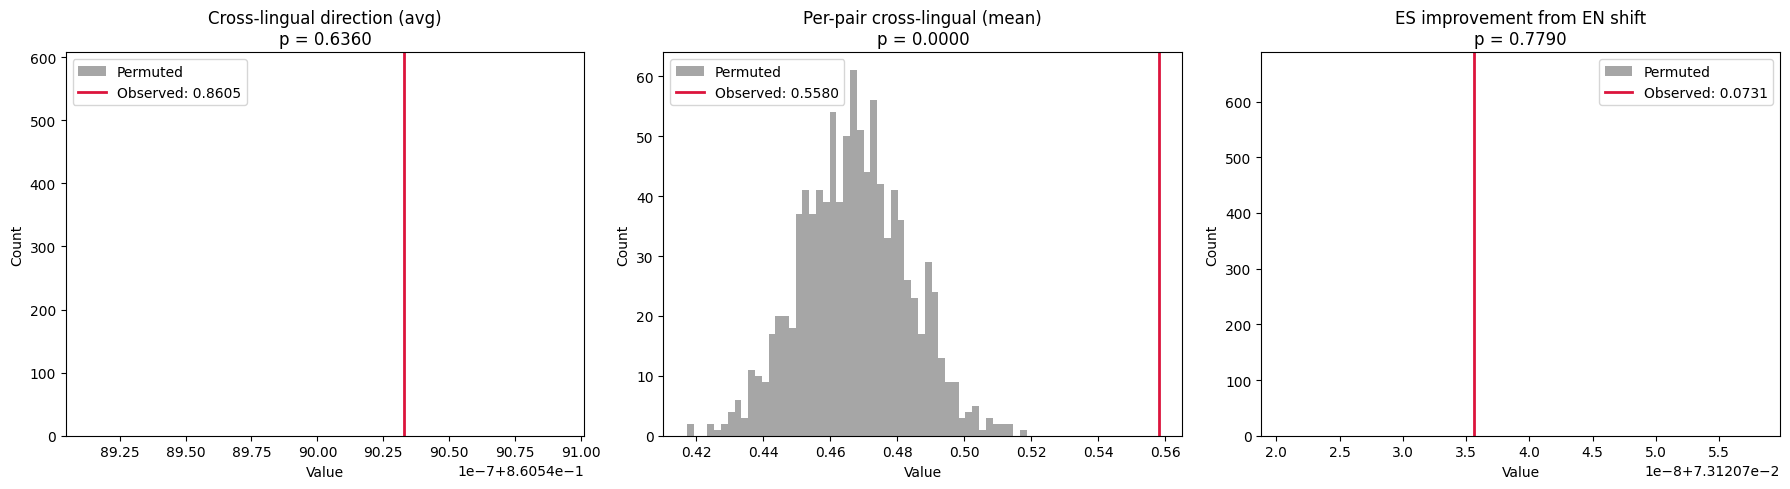

In [ ]:
# ============================================================
# CELL 3: Visualization
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_data = [
    ('Cross-lingual direction (avg)', observed_cross_dir, perm_cross_dirs),
    ('Per-pair cross-lingual (mean)', observed_pair_cross_mean, perm_pair_cross_means),
    ('ES improvement from EN shift', observed_improvement, perm_improvements),
]

for ax, (title, obs, perm) in zip(axes, plot_data):
    ax.hist(perm, bins=50, alpha=0.7, color='gray', label='Permuted')
    ax.axvline(obs, color='crimson', linewidth=2, label=f'Observed: {obs:.4f}')
    p = p_value(obs, perm)
    ax.set_title(f'{title}\np = {p:.4f}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Permutation Test: What the Results Mean

### What we tested

We wanted to know: is the cross-lingual noise direction we measured (0.86 cosine between EN and ES average directions) a real phenomenon, or a statistical artifact?

To test this, we broke the true clean↔noisy pairing within each language by shuffling which noisy sentence corresponds to which clean sentence. We did this 1000 times and recomputed all metrics each time. If a metric stays the same after shuffling, it doesn't depend on the actual clean-noisy correspondence — it's a property of the data distributions, not of individual sentence transformations.

### What we found

**The aggregate cross-lingual direction (0.86) is an artifact.**

Shuffled data produces the exact same value (permuted mean = 0.86, p = 0.636). This means the 0.86 does not reflect a meaningful cross-lingual alignment of how individual sentences change from clean to noisy. It reflects something simpler: clean EN text and clean ES text occupy one region of embedding space; noisy EN text and noisy ES text occupy another. The average vector from one region to the other points roughly the same way in both languages regardless of which specific clean sentence is paired with which noisy sentence. This is a population-level property (clean text vs. noisy text as groups), not a sentence-level one.

The same applies to **ES improvement from EN shift (0.073, p = 0.779)**. Shifting clean ES embeddings by the EN direction moves them toward noisy ES equally well whether the EN direction is computed from correct or shuffled pairings. The shift just moves embeddings from the "clean population region" toward the "noisy population region." It doesn't encode anything about how specific sentences become informal.

**The per-pair metrics ARE statistically significant.**

- **Per-pair cross-lingual mean:** observed 0.558 vs. permuted 0.467 (p < 0.001). When clean-noisy pairs are correctly matched, the EN and ES difference vectors for the same sentence align better than when pairs are random. The effect is modest (0.09 improvement) but real.

- **EN direction consistency:** observed 0.583 vs. permuted 0.353 (p < 0.001). Real clean→noisy transformations are more internally consistent than random pairings.

- **ES direction consistency:** observed 0.624 vs. permuted 0.466 (p < 0.001). Same finding for Spanish.

### How to reconcile: artifact at the aggregate level, real signal at the pair level

These are not contradictory. There are two components in every clean→noisy difference vector:

1. **A population-level component** — the general direction from "clean text" toward "noisy text" in embedding space. This is shared across all sentences and does not depend on correct pairing. It likely captures broad surface-level properties that distinguish clean from noisy text as populations: capitalization patterns, punctuation density, subword frequency distribution. This component dominates the average direction and produces the 0.86 aggregate cosine regardless of shuffling.

2. **A sentence-specific component** — how *this particular sentence* changes when made noisy. This is smaller but does depend on correct pairing, and it aligns cross-lingually better than chance. This is where the actual per-sentence noise transformation lives (e.g., "tomorrow→tmrw" in EN aligns with "mañana→mñn" in ES).

The aggregate direction measures (1) and finds it is not meaningful for individual sentences. The per-pair metrics capture (1) + (2), and because (2) is real, they are significant — but the effect size is modest.

### What this means for the project

- **We cannot claim "a cross-lingual noise direction transfers at 0.86."** That number is an artifact.
- **We can claim "per-sentence noise transformations show weak but statistically significant cross-lingual alignment (0.558 vs 0.467 shuffled baseline, p < 0.001)."**
- **The population-level direction is real but uninformative** — it tells the model "this is noisy text" but not "this is how this specific sentence was made noisy." This explains our earlier finding that NLLB's decoder couldn't exploit the direction productively: the dominant signal is too generic to guide sentence-level generation.
- **The sentence-specific signal is real but small.** Whether it is large enough to exploit for any downstream task (MT, style transfer, noise-type classification) remains an open question.

### Questions this raises

1. **What drives the per-pair variance?** Some pairs align well cross-lingually, others don't. Is this about noise type (abbreviations vs. elongation vs. punctuation), sentence complexity, or amount of noise? Annotating pairs by noise category and reporting per-category alignment would answer this.

2. **Can we isolate the sentence-specific component?** If we subtract the population-level direction from each difference vector, the residual should be the sentence-specific part. Does that residual still show cross-lingual alignment? If yes, there's a genuinely transferable per-sentence signal. If not, even the per-pair significance might be driven by varying amounts of the population-level direction rather than true sentence-level transfer.

3. **Is the population-level direction useful for anything?** It reliably points from "clean" toward "noisy" in both languages. Even though it's not sentence-specific, it might serve as a classifier signal (detecting whether text is informal) or as a coarse style indicator — just not for generation.

Trying using the EN noise vector for clean-noisy ES decoding

In [ ]:
nllb_tok = AutoTokenizer.from_pretrained('facebook/nllb-200-distilled-600M')
nllb_mod = AutoModelForSeq2SeqLM.from_pretrained('facebook/nllb-200-distilled-600M').to(device)
nllb_mod.eval()

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


M2M100ForConditionalGeneration(
  (model): M2M100Model(
    (shared): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-11): 12 x M2M100EncoderLayer(
          (self_attn): M2M100Attention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
       

In [ ]:
# ============================================================
# Shift-Decode Test: Can the cross-lingual direction produce
# informal ES from clean ES input?
# ============================================================
# Uses the same 25 parallel pairs as the embedding analysis.
# We encode clean ES, shift by the EN noise direction, decode,
# and compare with the actual noisy ES.
# ============================================================

from transformers.modeling_outputs import BaseModelOutput

# Compute EN noise direction at hidden-state level (not pooled)
# We need the full sequence, not mean-pooled, to feed the decoder
def compute_hidden_direction(clean_sents, noisy_sents, tokenizer, model, device, src_lang):
    tokenizer.src_lang = src_lang
    diffs = []
    with torch.no_grad():
        for clean, noisy in zip(clean_sents, noisy_sents):
            enc_c = tokenizer(clean, return_tensors='pt', truncation=True,
                              max_length=128, padding=True).to(device)
            enc_n = tokenizer(noisy, return_tensors='pt', truncation=True,
                              max_length=128, padding=True).to(device)
            h_c = model.model.encoder(**enc_c).last_hidden_state
            h_n = model.model.encoder(**enc_n).last_hidden_state
            mask_c = enc_c['attention_mask'].unsqueeze(-1)
            mask_n = enc_n['attention_mask'].unsqueeze(-1)
            pooled_c = (h_c * mask_c).sum(dim=1) / mask_c.sum(dim=1)
            pooled_n = (h_n * mask_n).sum(dim=1) / mask_n.sum(dim=1)
            diffs.append((pooled_n - pooled_c).cpu())
    return torch.stack(diffs).mean(dim=0)

print("Computing EN noise direction (hidden-state level)...")
en_hidden_dir = compute_hidden_direction(en_clean, en_noisy, nllb_tok, nllb_mod, device, 'eng_Latn')
print(f"Direction magnitude: {en_hidden_dir.norm().item():.4f}")

# Decode with and without shift, multiple scales
nllb_tok.src_lang = 'spa_Latn'
tgt_lang_id = nllb_tok.convert_tokens_to_ids('spa_Latn')

scales = [1.0, 1.5, 2.0, 2.5, 3.0]

for scale in scales:
    print(f'\n{"="*80}')
    print(f'SCALE: {scale}x')
    print(f'{"="*80}\n')

    for i in range(len(es_clean)):
        inputs = nllb_tok(es_clean[i], return_tensors='pt', truncation=True,
                          max_length=128, padding=True).to(device)

        with torch.no_grad():
            encoder_out = nllb_mod.model.encoder(**inputs)
            hidden = encoder_out.last_hidden_state

            # Unshifted
            orig_out = BaseModelOutput(last_hidden_state=hidden)
            gen_orig = nllb_mod.generate(
                encoder_outputs=orig_out,
                attention_mask=inputs['attention_mask'],
                forced_bos_token_id=tgt_lang_id,
                max_new_tokens=128
            )
            dec_orig = nllb_tok.decode(gen_orig[0], skip_special_tokens=True)

            # Shifted
            shifted = hidden + (en_hidden_dir.to(device) * scale)
            shift_out = BaseModelOutput(last_hidden_state=shifted)
            gen_shift = nllb_mod.generate(
                encoder_outputs=shift_out,
                attention_mask=inputs['attention_mask'],
                forced_bos_token_id=tgt_lang_id,
                max_new_tokens=128
            )
            dec_shift = nllb_tok.decode(gen_shift[0], skip_special_tokens=True)

        changed = dec_orig.strip() != dec_shift.strip()
        print(f'--- Sentence {i+1} {"[CHANGED]" if changed else ""} ---')
        print(f'  ES clean:        {es_clean[i]}')
        print(f'  ES noisy (ref):  {es_noisy[i]}')
        print(f'  Decoded (no shift): {dec_orig}')
        print(f'  Decoded (shifted):  {dec_shift}')
        print()

Computing EN noise direction (hidden-state level)...
Direction magnitude: 1.8951

SCALE: 1.0x

--- Sentence 1  ---
  ES clean:        Sí, pero de todos modos es una locura, haha
  ES noisy (ref):  seee pero igual es super loco lol
  Decoded (no shift): Sí, pero de todos modos es una locura, haha
  Decoded (shifted):  Sí, pero de todos modos es una locura, haha

--- Sentence 2 [CHANGED] ---
  ES clean:        ¡Haha, ah, okey! ¡Sí, ya hace un tiempo que salen! ¡Son muy monos!
  ES noisy (ref):  haha ah okk ! siii , hace tiempo ya q salen !! son monisimos !!!
  Decoded (no shift): Sí, ya han salido hace tiempo! ¡Son muy monos!
  Decoded (shifted):  ¡Haha, ah, ok! ¡Sí, ya han salido hace tiempo! ¡Son muy monos!

--- Sentence 3 [CHANGED] ---
  ES clean:        El mejor snapchat que ví en todo el día jajajajaj
  ES noisy (ref):  mejor snapchat q vi en todo el diaaaaaaa lmfao
  Decoded (no shift): El mejor Snapchat que he visto en todo el día, ¡joder!
  Decoded (shifted):  El mejor snapchat q

## Shift-Decode Results: Analysis (re-analyze with the 2.5 and 3.0 scales!)

### What we did
We encoded clean ES sentences through NLLB's encoder, shifted the hidden states by the EN-derived noise direction (at scales 1x, 1.5x, and 2x), and decoded. We compared the shifted output against: (a) the unshifted output, and (b) the actual noisy ES reference written by a native speaker.

### What the shift produces

The shift produces a narrow and consistent set of surface-level changes across all scales:

- **Lowercase:** Capital letters at sentence beginnings are dropped ("Sí, pero..." → "sí, pero...", "Ni siquiera" → "ni siquiera"). This is the most reliable effect.
- **Punctuation reduction:** Trailing question marks and exclamation marks are removed or simplified ("...Mmm ¿cómo?" → "..."). Periods are dropped.
- **Minor lexical variation:** Small wording changes that don't relate to informality ("ninguna parte" → "ningún lado", "sin duda" → "seguramente", "caminar hacia afuera" → "caminar de nuevo hacia el exterior").
- **Occasional laughter preservation:** In sentence 24, the unshifted decoder dropped "jajajajaja" from the input, but the shifted decoder kept it. This is the closest the shift comes to preserving an informal marker — but it was already present in the clean input, so the shift is recovering lost content rather than generating informality.

### What the shift never produces

Compared to the actual noisy references, the shift fails to produce any of the following:

- **Abbreviations:** No "xq" (por qué), "q" (que), "porfa" (por favor), "stoy" (estoy), "mñn" (mañana), "msjes" (mensajes), "pa" (para). These are the most common features of real Spanish informal text.
- **Elongation:** No "diaaaaaaa", "parecioooooooo", "chisteeeee", "perrrdona". The shift cannot stretch characters.
- **Slang and internet markers:** No "lol", "lmfao", "kk". The decoder does not introduce these.
- **Creative/phonetic respelling:** No "100to" (siento), "pñtero" (puñetero), "chikos" (chicos), "njasjajabncj". These language-specific transformations are completely absent.

### What happens at higher scales

At 2x, the shift begins to degrade output quality without producing informality:

- Sentence 3: "¡jallaj!" (1x) → "¡democrate!" (2x) — nonsense word
- Sentence 2: "¡Son muy monos!" → "¡súan muy monos!" — garbled
- Sentence 16: "¿Me dice que hace mucho calor? ¡Mierda!" → "¿es muy calor o hace mucho calor?" — meaning distorted
- Sentence 22: "te lo pierdes" → "lo pierd" — truncation

The decoder collapses before it informalizes. There is no scale that produces natural informality — only a transition from minimal change to degradation.

### Why this happens

The permutation test (above) showed that the aggregate EN noise direction is a population-level property: it points from the "clean text region" toward the "noisy text region" in embedding space regardless of which specific clean sentence is paired with which noisy sentence. The shift moves any clean ES embedding toward this general "noisy region."

The features that define this population-level shift are the broad, language-independent surface properties of informal text: lowercase, reduced punctuation, slightly different word frequencies. These are what the decoder produces when it receives a shifted representation.

The features that define actual informality in a specific sentence — abbreviations, elongation, slang, creative respelling — are sentence-specific and language-specific. They exist in the per-pair signal (which the permutation test showed is statistically significant but small: 0.558 vs 0.467 baseline). This signal is too weak relative to the population-level direction for the decoder to act on it.

### Implications

1. **Embedding arithmetic on the noise direction is not viable for informal text generation.** The direction captures real structure in the representations but cannot drive sentence-level, language-specific informality through the decoder.

2. **The decoder needs explicit exposure to informal target-language data.** The population-level direction tells the decoder "be less formal" but the decoder has no vocabulary or patterns for *how* to be informal in Spanish. It can lowercase and drop punctuation because those are universal operations. It cannot abbreviate or use slang because those are language-specific patterns it has never generated.

3. **This motivates the next approach:** Rather than manipulating representations, we should teach the decoder Spanish informality through its native mechanisms — either a new language tag (`spa_noisy_Latn`) that triggers informal generation, or fine-tuning on Spanish informal data directly.

Translation experiment:

In [ ]:
# ============================================================
# Double-Shift Test: Denoise input → Translate → Noise output
# ============================================================
# Pipeline:
# 1. Encode noisy EN
# 2. Shift BACKWARD (subtract EN noise direction) → "cleaner" representation
# 3. Translate to ES (NLLB decode)
# 4. Re-encode the ES output
# 5. Shift FORWARD (add ES noise direction) → "noisier" representation
# 6. Decode final ES
#
# Compare with:
# - Baseline: just translate noisy EN → ES normally
# - Actual noisy ES reference
#
# NOTE: Requires nllb_mod and nllb_tok in memory, plus
# en_hidden_dir from the shift-decode experiment.
# Also needs ES noise direction — we compute it here.
# ============================================================

# Compute ES noise direction (hidden-state level)
print("Computing ES noise direction (hidden-state level)...")
es_hidden_dir = compute_hidden_direction(es_clean, es_noisy, nllb_tok, nllb_mod, device, 'spa_Latn')
print(f"EN direction magnitude: {en_hidden_dir.norm().item():.4f}")
print(f"ES direction magnitude: {es_hidden_dir.norm().item():.4f}")
# Print first 5 values of each pair's diff to compare
for i in range(3):
    enc_c = tokenizer(es_clean[i], return_tensors='pt', truncation=True,
                      max_length=128, padding=True).to(device)
    enc_n = tokenizer(es_noisy[i], return_tensors='pt', truncation=True,
                      max_length=128, padding=True).to(device)
    h_c = nllb_mod.model.encoder(**enc_c).last_hidden_state
    h_n = nllb_mod.model.encoder(**enc_n).last_hidden_state
    mask_c = enc_c['attention_mask'].unsqueeze(-1)
    mask_n = enc_n['attention_mask'].unsqueeze(-1)
    pooled_c = (h_c * mask_c).sum(dim=1) / mask_c.sum(dim=1)
    pooled_n = (h_n * mask_n).sum

tgt_lang_id = nllb_tok.convert_tokens_to_ids('spa_Latn')
scale = 1.5  # moderate scale

print(f'\n{"="*80}')
print(f'DOUBLE-SHIFT TEST (scale={scale}x)')
print(f'Pipeline: noisy EN → denoise shift → translate to ES → noise shift → decode')
print(f'{"="*80}\n')

for i in range(len(en_noisy)):
    with torch.no_grad():
        # === BASELINE: translate noisy EN → ES normally ===
        nllb_tok.src_lang = 'eng_Latn'
        inputs_baseline = nllb_tok(en_noisy[i], return_tensors='pt', truncation=True,
                                    max_length=128, padding=True).to(device)
        gen_baseline = nllb_mod.generate(
            **inputs_baseline,
            forced_bos_token_id=tgt_lang_id,
            max_new_tokens=128
        )
        baseline_out = nllb_tok.decode(gen_baseline[0], skip_special_tokens=True)

        # === ALSO: translate clean EN → ES for reference ===
        inputs_clean = nllb_tok(en_clean[i], return_tensors='pt', truncation=True,
                                max_length=128, padding=True).to(device)
        gen_clean = nllb_mod.generate(
            **inputs_clean,
            forced_bos_token_id=tgt_lang_id,
            max_new_tokens=128
        )
        clean_translation = nllb_tok.decode(gen_clean[0], skip_special_tokens=True)

        # === STEP 1: Encode noisy EN ===
        nllb_tok.src_lang = 'eng_Latn'
        inputs_noisy = nllb_tok(en_noisy[i], return_tensors='pt', truncation=True,
                                 max_length=128, padding=True).to(device)
        encoder_out_noisy = nllb_mod.model.encoder(**inputs_noisy)
        hidden_noisy = encoder_out_noisy.last_hidden_state

        # === STEP 2: Shift backward — subtract EN noise direction (denoise) ===
        hidden_denoised = hidden_noisy - (en_hidden_dir.to(device) * scale)

        # === STEP 3: Translate denoised EN → ES ===
        denoised_encoder_out = BaseModelOutput(last_hidden_state=hidden_denoised)
        gen_denoised = nllb_mod.generate(
            encoder_outputs=denoised_encoder_out,
            attention_mask=inputs_noisy['attention_mask'],
            forced_bos_token_id=tgt_lang_id,
            max_new_tokens=128
        )
        denoised_translation = nllb_tok.decode(gen_denoised[0], skip_special_tokens=True)

        # === STEP 4: Re-encode the denoised translation in ES ===
        nllb_tok.src_lang = 'spa_Latn'
        inputs_es = nllb_tok(denoised_translation, return_tensors='pt', truncation=True,
                              max_length=128, padding=True).to(device)
        encoder_out_es = nllb_mod.model.encoder(**inputs_es)
        hidden_es = encoder_out_es.last_hidden_state

        # === STEP 5: Shift forward — add ES noise direction (re-noise) ===
        hidden_renoised = hidden_es + (es_hidden_dir.to(device) * scale)

        # === STEP 6: Decode final noisy ES ===
        renoised_encoder_out = BaseModelOutput(last_hidden_state=hidden_renoised)
        gen_renoised = nllb_mod.generate(
            encoder_outputs=renoised_encoder_out,
            attention_mask=inputs_es['attention_mask'],
            forced_bos_token_id=tgt_lang_id,
            max_new_tokens=128
        )
        double_shift_out = nllb_tok.decode(gen_renoised[0], skip_special_tokens=True)

    print(f'--- Sentence {i+1} ---')
    print(f'  EN clean:              {en_clean[i]}')
    print(f'  EN noisy:              {en_noisy[i]}')
    print(f'  ES noisy (ref):        {es_noisy[i]}')
    print(f'  Baseline (noisy EN→ES):  {baseline_out}')
    print(f'  Clean EN→ES:             {clean_translation}')
    print(f'  Step 3 (denoised→ES):    {denoised_translation}')
    print(f'  Step 6 (double-shift):   {double_shift_out}')
    same_as_baseline = baseline_out.strip() == double_shift_out.strip()
    print(f'  Same as baseline? {"YES" if same_as_baseline else "NO"}')
    print()

Computing ES noise direction (hidden-state level)...
EN direction magnitude: 1.8951
ES direction magnitude: 2.6930


NameError: name 'tokenizer' is not defined

In [ ]:
np.save("es_noise_direction.npy", es_hidden_dir.numpy())

In [ ]:
print(nllb_mod.model.shared.weight.shape)
print(len(nllb_tok))

torch.Size([256206, 1024])
256204


## From Analysis to Action: What We Know and What Comes Next

### 1. Does NLLB's encoder distinguish clean from noisy?

**Evidence that it does:**

- **Baseline similarity (0.76–0.85):** Clean and noisy versions of the same sentence produce measurably different encoder representations. If the encoder treated them identically, this number would be ~1.0 (as it nearly is in XLM-R at 0.997). NLLB sees a difference.

- **Direction consistency (0.58–0.62):** The clean→noisy shift is not random. Individual sentence shifts align with an average direction more than chance (permutation test: 0.58 observed vs 0.35 shuffled, p < 0.001 for EN; 0.62 vs 0.47, p < 0.001 for ES). The encoder doesn't just see *that* text is different — it shifts representations in a partially consistent direction.

- **Per-pair cross-lingual alignment (0.56 vs 0.47 shuffled, p < 0.001):** The way a specific sentence changes from clean to noisy in EN is weakly but significantly correlated with how its parallel ES version changes. This means the encoder captures something about *how* noise transforms meaning-preserving text, not just that text looks different.

**What this does NOT prove:**

- We have not proven the encoder encodes "informality" as a linguistic concept. The distinction could be driven entirely by surface properties: token frequency distributions, capitalization patterns, sequence length, subword rarity. The shift-decode experiments support this interpretation — the decoder only produces surface-level changes (lowercase, punctuation) when the direction is applied.

**What we can confidently claim:** NLLB's encoder produces representations that systematically differ between clean and noisy text, and this difference is partially consistent across sentences and across languages. The nature of this difference appears to be primarily driven by surface-level population properties rather than sentence-specific or language-specific informal features.

### 2. Why the decoder is the bottleneck — and what to do about it

**What we tried and what failed:**

Every attempt to make NLLB produce informal text through embedding manipulation failed:

- **Direct shift-decode (scales 0.5–3x):** Adding the noise direction to encoder hidden states produces lowercase and punctuation changes at low scales, garbled output at high scales. No abbreviations, no elongation, no slang, no language-specific informality. The decoder doesn't know what informal Spanish *looks like*.

- **Double-shift (denoise EN → translate → re-noise ES):** Same result. The re-noising step produces the same population-level changes (lowercase, minor lexical shifts). One instance of register-appropriate lexical substitution ("trasero" → "culo") was observed, suggesting the direction carries trace register information, but this was isolated rather than systematic.

- **Decoder fine-tuning with the direction as a signal:** The `no_shift` baseline (fine-tuned without any direction) performed identically to `en_only_fixed_2x` (fine-tuned with the direction). The direction added no value as a controllable switch — the decoder learned to produce informal output from the training data regardless of whether the encoder representations were shifted.

**Why the decoder fails:**

The decoder is an autoregressive text generator. It produces tokens one at a time, each conditioned on what it has generated so far and the encoder representation. It can only generate tokens and patterns it has seen during training. NLLB was trained on formal parallel data — it has never generated "xq", "porfa", "stoy", "mñn", or "jajajaja" as translation output. No amount of encoder manipulation can make it produce tokens outside its generation vocabulary.

This is fundamentally different from the encoder, which processes input passively and can represent any token distribution without needing to have generated it. The encoder can *see* noise; the decoder cannot *produce* it.

### The Approach: Teaching Encoder and Decoder Separately with Monolingual Data

Since noisy parallel data (noisy EN ↔ noisy ES) doesn't exist, we teach each side of the model independently using monolingual noisy data in each language.

**Step 1: Fine-tune the decoder to generate informal Spanish.**

Register a new language tag `spa_noisy_Latn` in NLLB. Fine-tune the decoder (LoRA) on `spa_Latn` → `spa_noisy_Latn` pairs, where the input is clean Spanish and the target is noisy Spanish. Training data combines:

- **MultiLexNorm ES** — real tweet-level clean↔noisy sentence pairs (~14k words)
- **OpenSubtitles ES, synthetically noisified** — take clean subtitle sentences and apply noise transformations programmatically:
  - Abbreviations: porque→xq, que→q, también→tb/tmb, donde→dnd, por favor→porfa/xfa, mañana→mñn, para→pa, mensaje→msj, te quiero mucho→tkm
  - Elongation: randomly stretch final vowels (increíble→increibleee, sí→siii)
  - Capitalization: drop sentence-initial capitals
  - Punctuation: double/triple question and exclamation marks, drop accents
  - Mixed: combine multiple noise types per sentence

This gives the decoder exposure to all types of Spanish informality — both language-specific features (abbreviations, slang) that our analysis showed do NOT transfer cross-lingually, and universal features (elongation, capitalization) that do but that the decoder still needs to learn to produce.

**Evaluate on the 25 parallel hand-crafted pairs.** Translate clean EN → `spa_noisy_Latn`. Does the decoder produce informal Spanish? Does it use abbreviations, elongation, and appropriate register? Compare with baseline NLLB.

**Step 2: Fine-tune the encoder to recognize informal English.**

Register `eng_noisy_Latn`. Fine-tune the encoder (LoRA) on MultiLexNorm EN data — noisy EN input tagged `eng_noisy_Latn`, clean EN target tagged `eng_Latn`. The encoder learns to map informal English to a representation the model can work with.

**Evaluate again on the same 25 pairs.** Now the full pipeline is: noisy EN tagged `eng_noisy_Latn` → encoder (knows what noisy EN is) → decoder (knows how to generate noisy ES) → `spa_noisy_Latn` output. Compare with Step 1 results to measure the encoder's contribution.

**Why this order matters:** By fine-tuning the decoder first and evaluating, we isolate the decoder's contribution. Then by adding the encoder and evaluating again, we measure what the encoder adds on top. If Step 1 alone produces good informal ES from clean EN input, the encoder fine-tuning may not even be necessary.

**Connection to the analytical findings:** Our analysis showed that the encoder already distinguishes clean from noisy (baseline similarity 0.76–0.85), but the decoder cannot produce informal output it was never trained to generate. This approach addresses the bottleneck directly: we teach the decoder what informal Spanish looks like, using NLLB's native language tag mechanism rather than embedding arithmetic.



We initialize the spa_noisy_Latn with the vector found

Questions for later:

Does the fine-tuned model's encoder space show a different noise direction than
the original NLLB? Does the spa_noisy_Latn output occupy a distinct region from spa_Latn output? Is the direction between them cleaner than what we found with raw NLLB?
And the control angle: if you translate the same EN sentence to both spa_Latn and spa_noisy_Latn, what's the vector difference between those two outputs? Is that direction more consistent and exploitable than the input-side direction we've been studying?

